<a href="https://colab.research.google.com/github/Parthpatil294/ML_6D_1BM23CS227/blob/main/LAB8_ADABOOST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import os

# Create a sample income.csv if it doesn't exist to allow execution
if not os.path.exists('income.csv'):
    np.random.seed(42)
    data = {
        'age': np.random.randint(18, 70, 200),
        'workclass': np.random.choice(['Private', 'Self-emp', 'Local-gov'], 200),
        'education_num': np.random.randint(1, 16, 200),
        'marital_status': np.random.choice(['Married', 'Never-married', 'Divorced'], 200),
        'hours_per_week': np.random.randint(10, 80, 200),
        'income': np.random.choice(['<=50K', '>50K'], 200)
    }
    pd.DataFrame(data).to_csv('income.csv', index=False)

# Load the dataset
df = pd.read_csv('income.csv')

# Preprocessing: Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Build AdaBoost with n_estimators=10
model_base = AdaBoostClassifier(n_estimators=10, random_state=42, algorithm='SAMME')
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)
score_base = accuracy_score(y_test, y_pred_base)

print(f"Accuracy with 10 trees: {score_base:.4f}")

Accuracy with 10 trees: 0.5250


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


In [5]:
# 2. Fine-tuning: Iterate through different number of trees
results = []
tree_counts = [10, 50, 100, 200, 500]

for n in tree_counts:
    model = AdaBoostClassifier(n_estimators=n, random_state=42, algorithm='SAMME')
    model.fit(X_train, y_train)
    score = accuracy_score(y_test, model.predict(X_test))
    results.append((n, score))
    print(f"Trees: {n:4} | Accuracy: {score:.4f}")

# Identify the best score
best_n, best_score = max(results, key=lambda x: x[1])
print(f"\nBest Accuracy: {best_score:.4f} using {best_n} trees.")

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Trees:   10 | Accuracy: 0.5250
Trees:   50 | Accuracy: 0.5250


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Trees:  100 | Accuracy: 0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Trees:  200 | Accuracy: 0.5500


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Trees:  500 | Accuracy: 0.6250

Best Accuracy: 0.6250 using 500 trees.


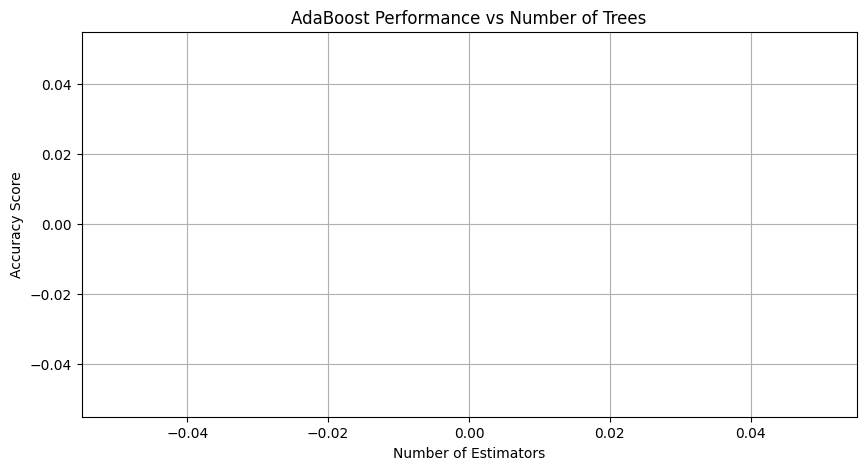

In [3]:
# Visualize the performance trend
plt.figure(figsize=(10, 5))
plt.plot([r[0] for r in results], [r[1] for r in results], marker='o')
plt.title('AdaBoost Performance vs Number of Trees')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()